In [1]:

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
pd.options.mode.chained_assignment = None

import pyfade

In [2]:
# from scipy.signal import butter, lfilter, freqz
# from scipy.linalg import pascal
# # Set filter
# fs = 1
# btype = 'pass'
# if btype == 'pass':
#     T_cutoff = np.array([50,6])
# else:
#     T_cutoff = 6

# cutoff = 1/T_cutoff
# order = 7




# den_diff = 1
# num_diff = 1
# num_butter = 1
# den_butter = 1

# use_butter = 0
# use_mean = 1

# n = 20
# if use_mean:
#     #den_diff = np.array([1])
#     #num_diff = np.concatenate(([n-1],[-1]*(n-1)))/n
#     num_diff = np.array(([1]*n))/n
#     # num_diff = pascal(n+1,kind='lower')[n,:n+2] * (-1)**np.arange(n+1) / 2**n
#     #num_diff = np.array([1,-1])

# if use_butter:
#     num_butter,den_butter = butter(order, cutoff,fs=fs,btype=btype)

# den = np.polymul(den_butter,den_diff)
# num = np.polymul(num_butter,num_diff)

# w, h = freqz(num, den, fs=fs)

# plt.figure(figsize=(8,4))
# plt.plot(w, np.abs(h), 'b')
# #plt.plot(w, (np.angle(h)*180/np.pi), 'b')
# plt.ylabel('Magnitude')
# plt.xlabel('Frequency [1/h]')
# plt.grid(True)




In [3]:
# t = np.arange(0,21)

# y = np.sin(0.7*t)

# yo = y.copy()

# yo[[0,1]] = np.nan
# yo[[-1,-2]] = np.nan
# yo[[3,8,9,16]] = np.nan

# y1 = np.ones(2)*yo[2]
# y2 = np.ones(2)*yo[-3]

# y3 = (y[2]+y[4])/2

# y4 = (y[7]*2+y[10])/3
# y5 = (y[7]+y[10]*2)/3

# y6 = (y[15]+y[17])/2


# f = plt.figure(figsize=(8,4))
# plt.plot(t,yo,'ro')
# plt.plot(t[[0,1]],y1,'go',fillstyle='none')
# plt.plot(t[[-1,-2]],y2,'go',fillstyle='none')
# plt.plot(t[[3]],y3,'bo',fillstyle='none')
# plt.plot(t[[8,9]],[y4,y5],'bo',fillstyle='none')
# plt.plot(t[[16]],y6,'bo',fillstyle='none')

# plt.xticks([0,5,10,15,20])
# plt.xlabel("Timestamp")
# plt.ylabel("Dataset")
# plt.grid(True)


In [4]:
WELL = 'B-18 2'
SOURCE = 'C:/Users/Heitor/Documents/Pesquisa/PosDoc/code/EPIC/Dados/merged_data.csv'
# EXAMPLE_SIGNAL = 'ESP motor temperature'
EXAMPLE_SIGNAL = None

In [ ]:
IGNORE_START = True

SUB_SIZE = 1*24

USE_CUDA = True
LEFT_ONLY=True
SKIP_START=SUB_SIZE*14
QUANTILE = 0.8

MP_PARAMS = {
    'use_cuda': USE_CUDA,
    'left_only': LEFT_ONLY,
    'skip_start': SKIP_START,
    'quantile_threshold': QUANTILE,
    # 'exclusion_zone_ratio':
}


LEVELS = 5
DIMENSION = 1
WAVELET = 'db4'
TYPE_ANAL = 'denoise'
DENOISE_THRESHOLD = 0.2


WAVELET_PARAMS = {
    'wavelet_total_level': LEVELS,
    'wavelet_aggregate_level': DIMENSION,
    'wavelet_analysis_type': TYPE_ANAL,
    'wavelet_type': WAVELET,
    'wavelet_denoise_threshold': DENOISE_THRESHOLD,
}

# 1 - Reading Signal

In [6]:
# Load well data
if 'well_data' not in locals():
    data_full = pyfade.load_data(SOURCE)
    well_data = pyfade.get_well_data(data_full, WELL, only_numerical=True, remove_ints=True, drop_na=True, drop_features = True)

shutdowns_all = pyfade.get_shutdowns(well_data)

In [7]:
if EXAMPLE_SIGNAL is not None:
    sub_data = well_data[EXAMPLE_SIGNAL]
    shutdowns = [shutdowns_all[well_data.columns.get_loc(EXAMPLE_SIGNAL)]]
else:
    sub_data = well_data.copy()
    shutdowns = shutdowns_all


In [8]:
sub_data.index

DatetimeIndex(['2011-12-26 21:00:00', '2011-12-26 22:00:00',
               '2011-12-26 23:00:00', '2011-12-27 00:00:00',
               '2011-12-27 01:00:00', '2011-12-27 02:00:00',
               '2011-12-27 05:00:00', '2011-12-27 06:00:00',
               '2011-12-27 07:00:00', '2011-12-27 08:00:00',
               ...
               '2013-04-25 07:00:00', '2013-04-25 08:00:00',
               '2013-04-25 09:00:00', '2013-04-25 10:00:00',
               '2013-04-25 11:00:00', '2013-04-25 12:00:00',
               '2013-04-25 13:00:00', '2013-04-25 14:00:00',
               '2013-04-25 15:00:00', '2013-04-25 16:00:00'],
              dtype='datetime64[ns]', name='time', length=9229, freq=None)

# 2 - MP raw

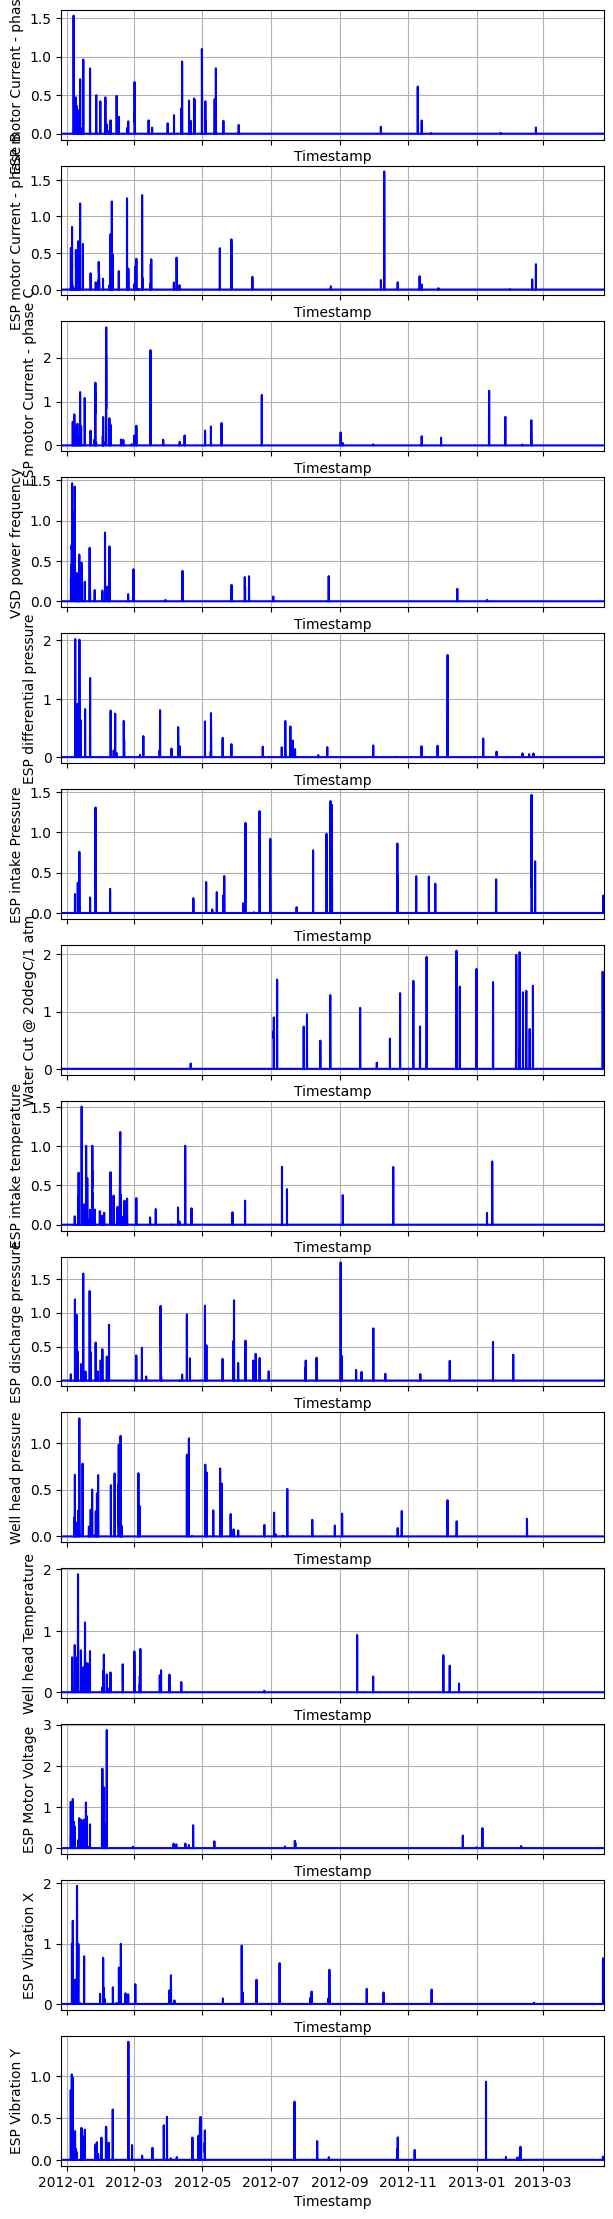

In [9]:
builder = pyfade.DataFrameBuilder(sub_data)
dataset = builder.set_extrapolation(pyfade.Extrapolation.CONSTANT)\
            .set_interpolation(pyfade.Interpolation.LINEAR)\
            .set_filter(pyfade.FilterType.BUTTER_LOW,4,1/12)\
            .build()

w_builder = pyfade.WindowBuilder(dataset)
window = w_builder.set_window_size(SUB_SIZE).build()

group_builder = pyfade.FeatureGroupBuilder(pyfade.FeatureGroups.MatrixProfile, window)
group_builder.set_parameters(MP_PARAMS)
group_builder.build()


# fig,axs = dataset.plot(height=2,width=7);

# lims = pd.to_datetime(['2019-04-01','2020-04-08'])
lims = None
fig, axs = window.plot_feature(pyfade.Features.MatProfileVal,xlimits=lims,height=2,width=7);



In [10]:
fig.savefig('MP_orig.png', format='png', dpi=300)

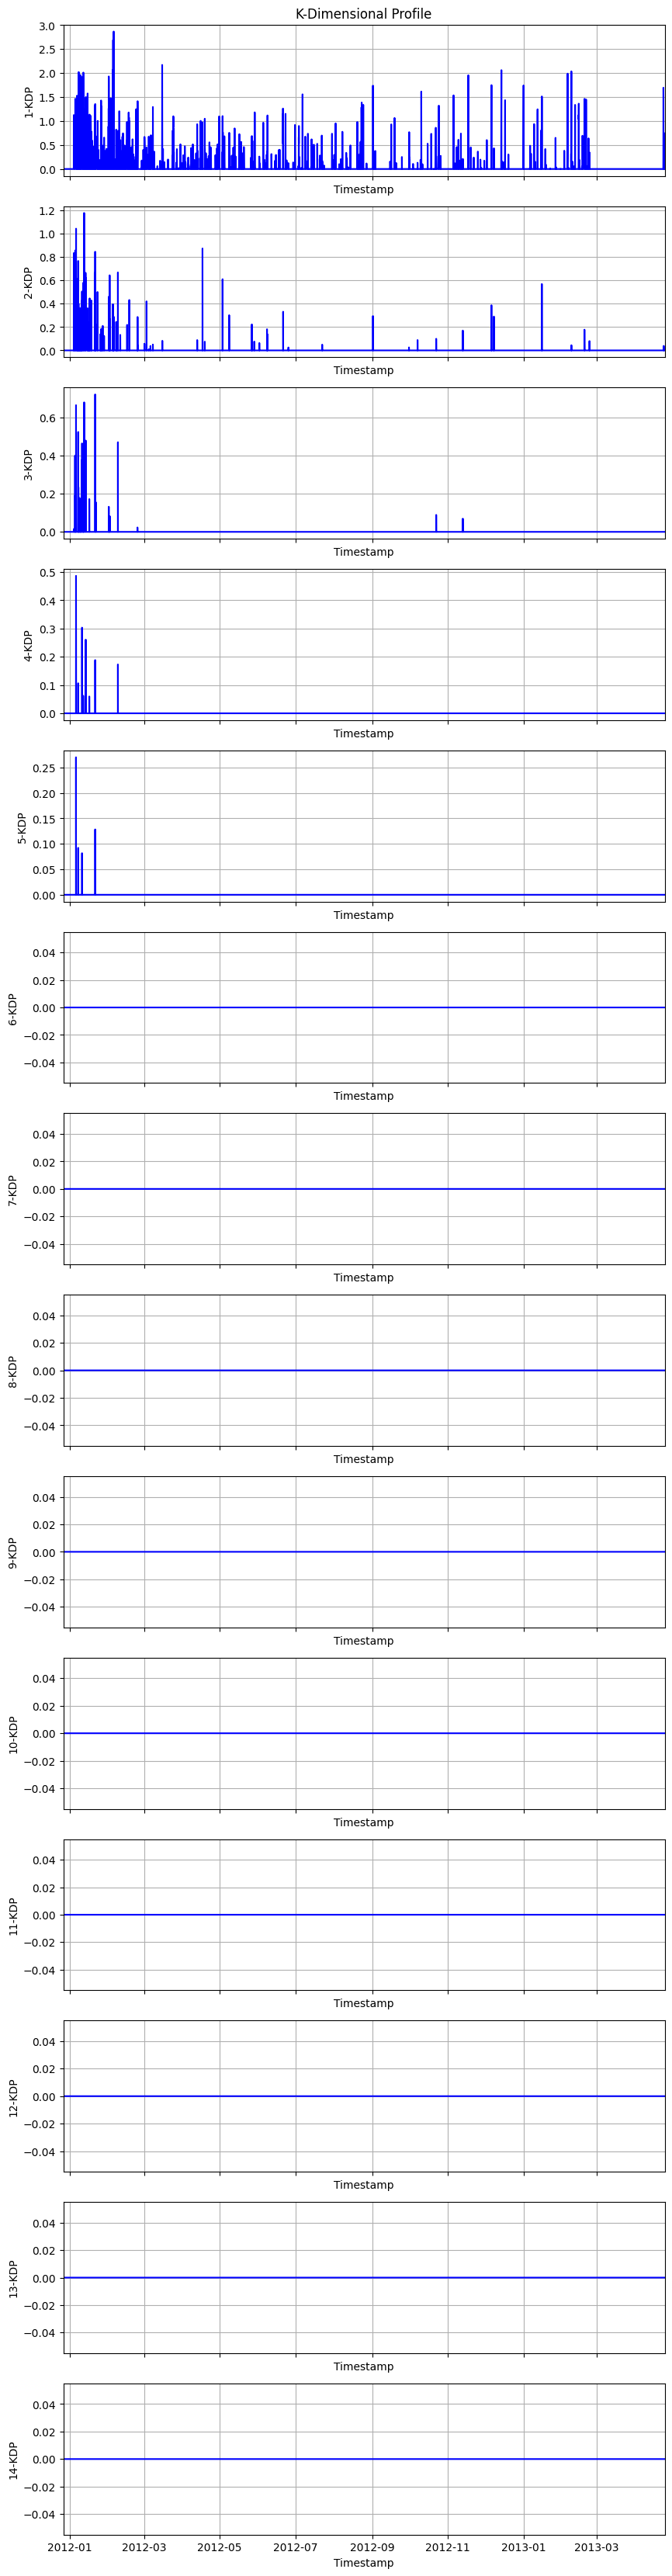

In [11]:
pyfade.FeatureGroupBuilder(pyfade.FeatureGroups.KProfile,window,replace=True).build()

# lims = pd.to_datetime(['2019-04-01','2020-04-08'])
window.plot_feature(pyfade.Features.KProfileVal,title='K-Dimensional Profile',xlimits=lims,fill_na=0);

# 3 - Decomposition

In [12]:
# group_builder = pyfade.FeatureGroupBuilder(pyfade.FeatureGroups.WaveletProfile,window,replace=True)
# group_builder.set_parameters(MP_PARAMS).set_parameters(WAVELET_PARAMS)
# group_builder.build()

# window.get_feature('decomposition')[0].plot();

# 4 - MP wavelet

In [33]:
WAVELET_PARAMS2 = WAVELET_PARAMS.copy()
WAVELET_PARAMS2['wavelet_total_level'] = 4
WAVELET_PARAMS2['wavelet_aggregate_level'] = 1
WAVELET_PARAMS2['wavelet_analysis_type'] = 'denoise'
WAVELET_PARAMS2['wavelet_type'] = 'db4'
WAVELET_PARAMS2['wavelet_denoise_threshold'] = 0.3

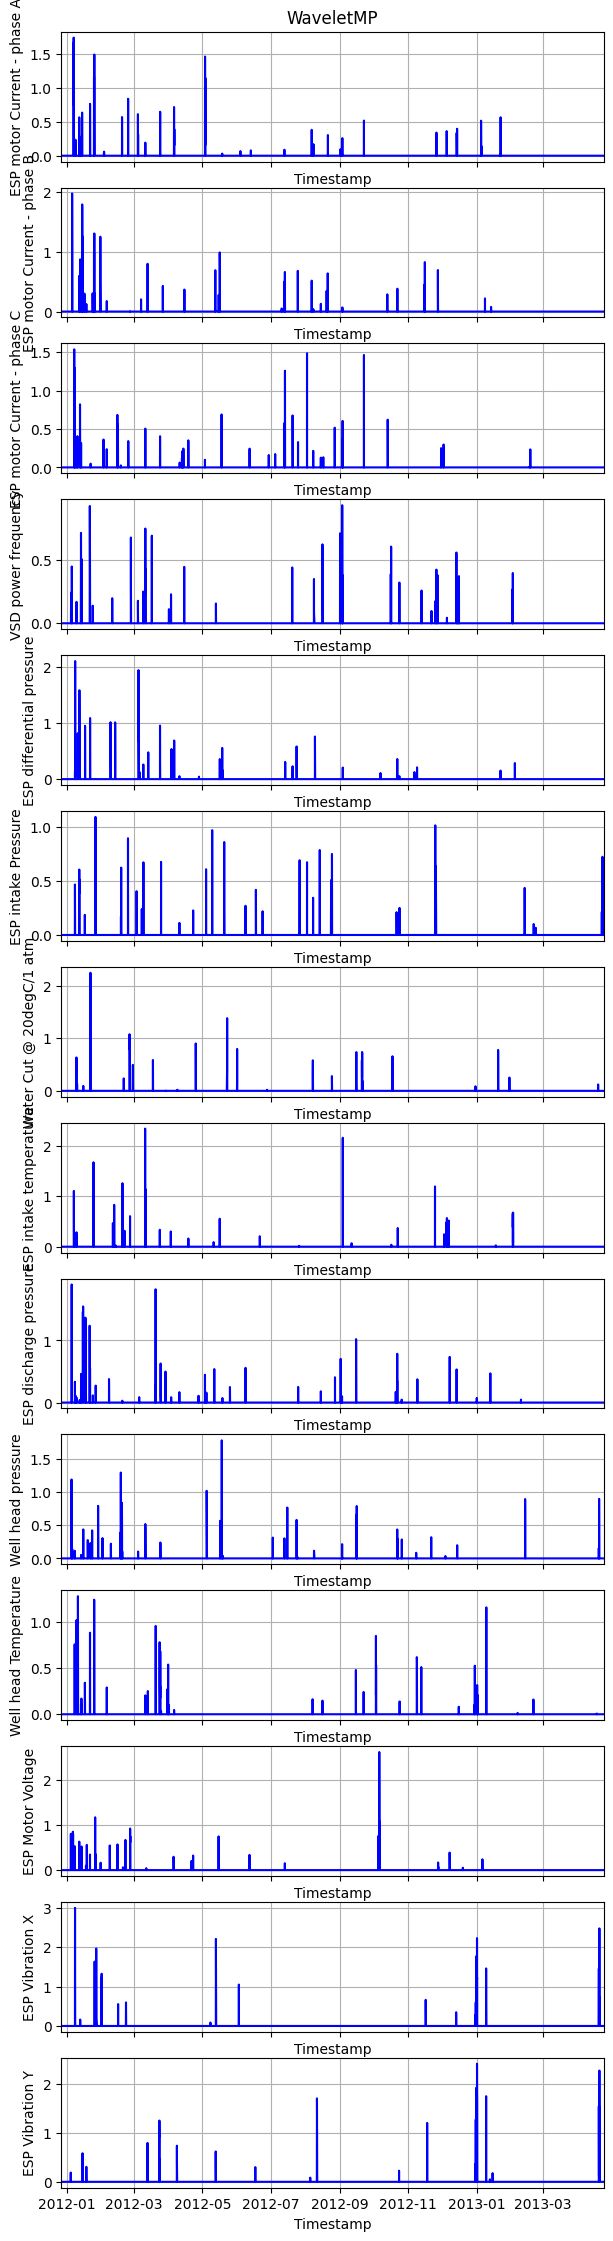

In [34]:
group_builder = pyfade.FeatureGroupBuilder(pyfade.FeatureGroups.WaveletProfile,window,replace=True)
group_builder.set_parameters(MP_PARAMS).set_parameters(WAVELET_PARAMS2)
group_builder.build()


fig,axs = window.plot_feature(pyfade.Features.WaveletMP,title='WaveletMP',xlimits=lims,height=2,width=7);


In [35]:
# fig.savefig('MP_wavelet_last.png', format='png', dpi=300)

In [36]:
group_builder = pyfade.FeatureGroupBuilder(pyfade.FeatureGroups.WaveletKProfile,window,replace=True)
group_builder.build()



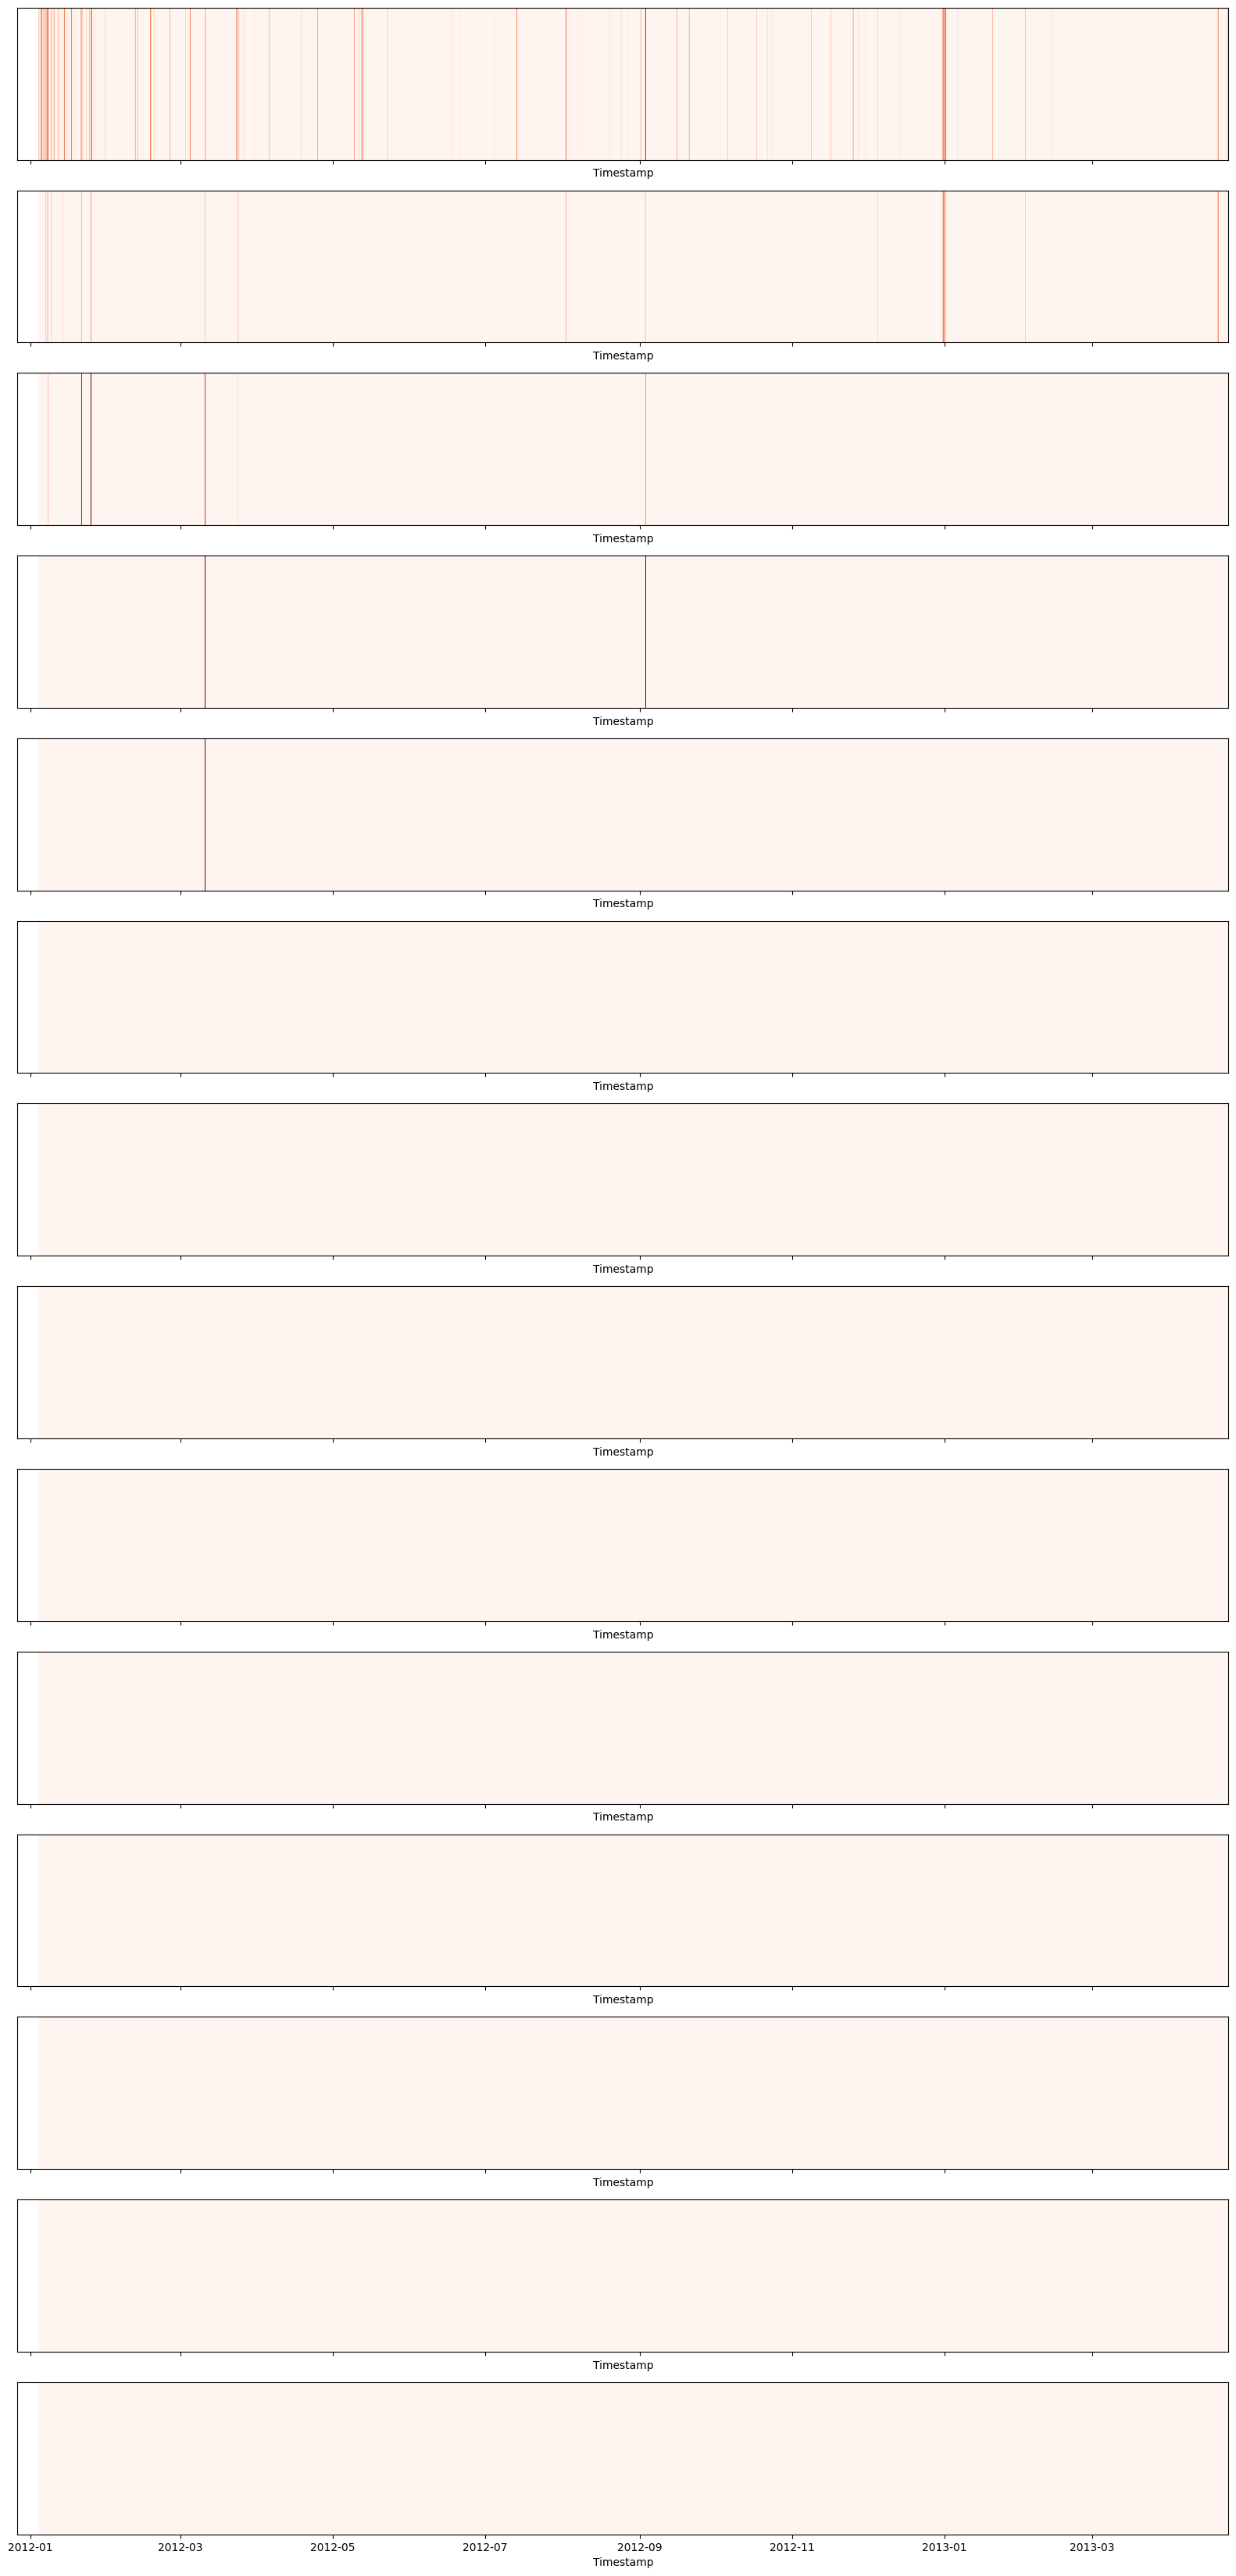

In [37]:
window.plot_color(pyfade.Features.WaveletKP,start=SKIP_START, scale='none',width=20);

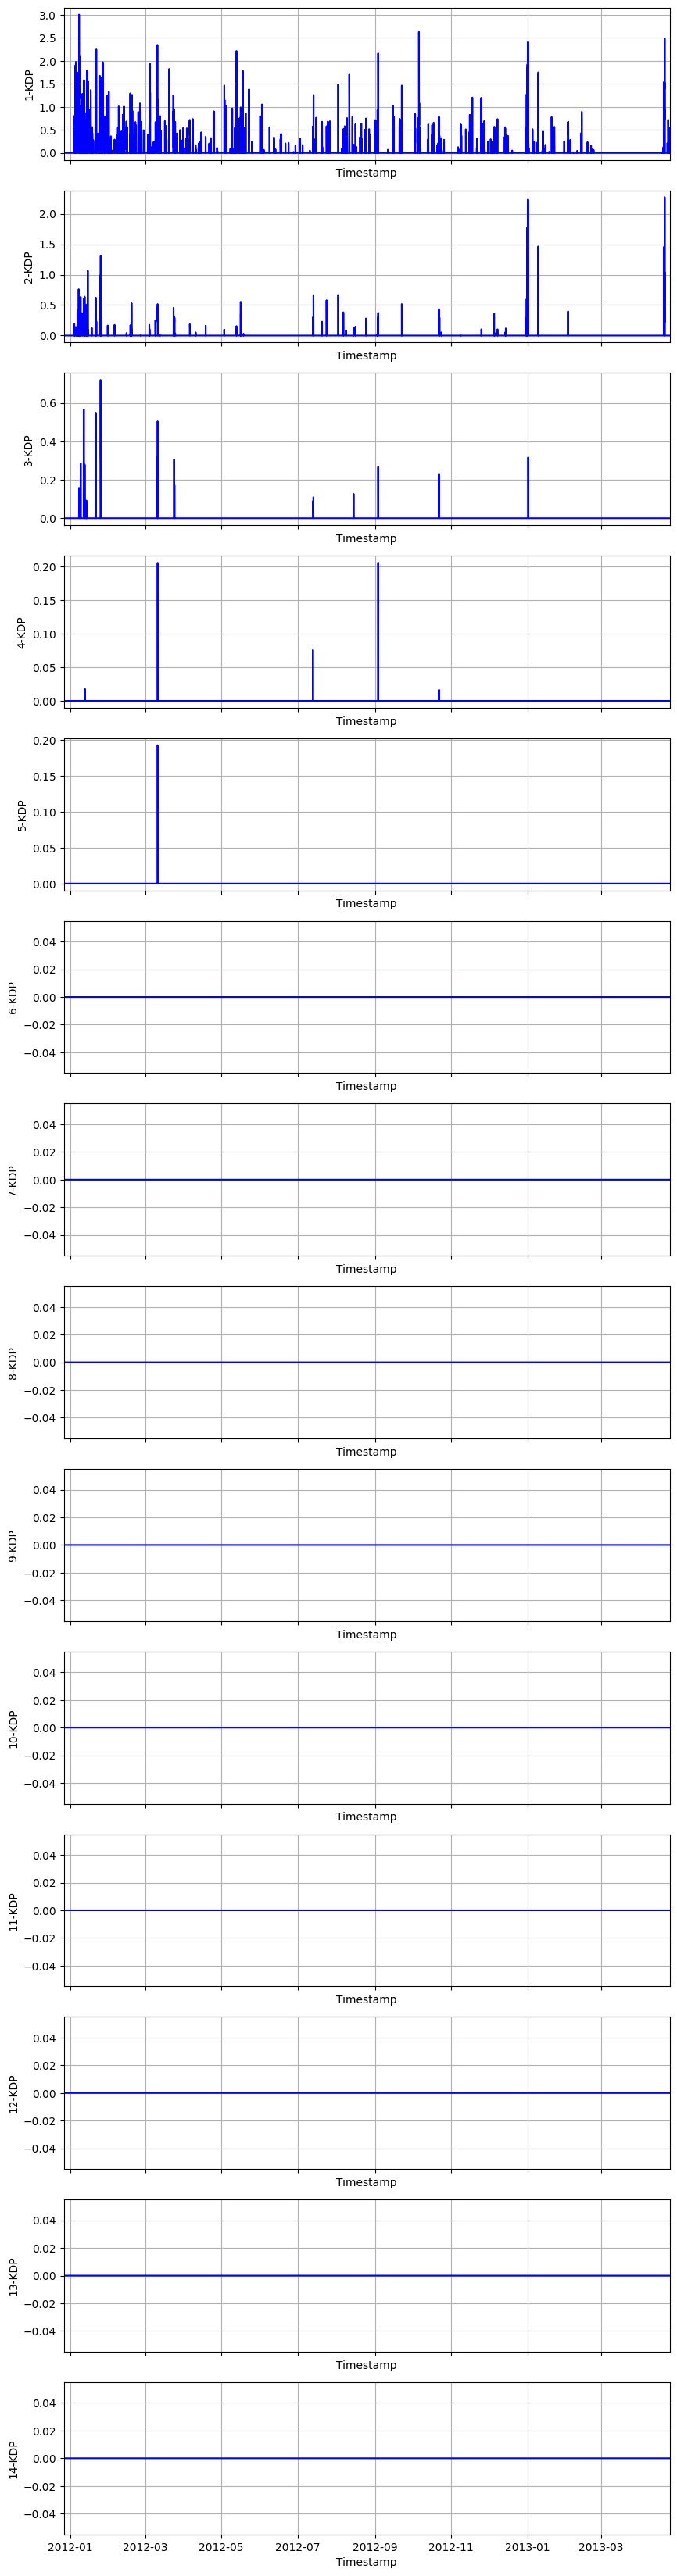

In [38]:
window.plot_feature(pyfade.Features.WaveletKP,xlimits=lims,fill_na=0);

In [39]:
# fig.savefig('All_MP.png', format='png', dpi=300)

In [40]:
# KDP = pyfade.get_KDP(sub_data,SUB_SIZE,pre_calc_MP=MPs,shutdowns=shutdowns,**mp_properties)
# fig, axs = pyfade.plot_multiple(KDP,same_limits=False,height=1, width=10,linewidth=2,style='r-');

In [41]:
# fig.savefig('All_KDP.png', format='png', dpi=300)